In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
lfw_people = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

print("Images :", lfw_people.images.shape)
print("Labels :", lfw_people.target.shape)
print("Classes :", len(lfw_people.target_names))
print(lfw_people.target_names)

Images : (1288, 50, 37)
Labels : (1288,)
Classes : 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


In [ ]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(lfw_people.images[i], cmap="gray")
    plt.title(lfw_people.target_names[lfw_people.target[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X = lfw_people.images
y = lfw_people.target

In [ ]:
X = X.reshape(-1,50,37,1)

In [3]:
X = lfw_people.images.astype("float32")
y = lfw_people.target
X = X.reshape(-1, 50, 37, 1)

print(X.min())
print(X.max())

0.0
1.0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1030, 50, 37, 1)
(258, 50, 37, 1)


In [5]:
import numpy as np

print("Classes:", np.unique(y_train))
print("Training distribution:")
print(np.bincount(y_train))

print("Testing distribution:")
print(np.bincount(y_test))

Classes: [0 1 2 3 4 5 6]
Training distribution:
[ 61 189  97 424  87  57 115]
Testing distribution:
[ 16  47  24 106  22  14  29]


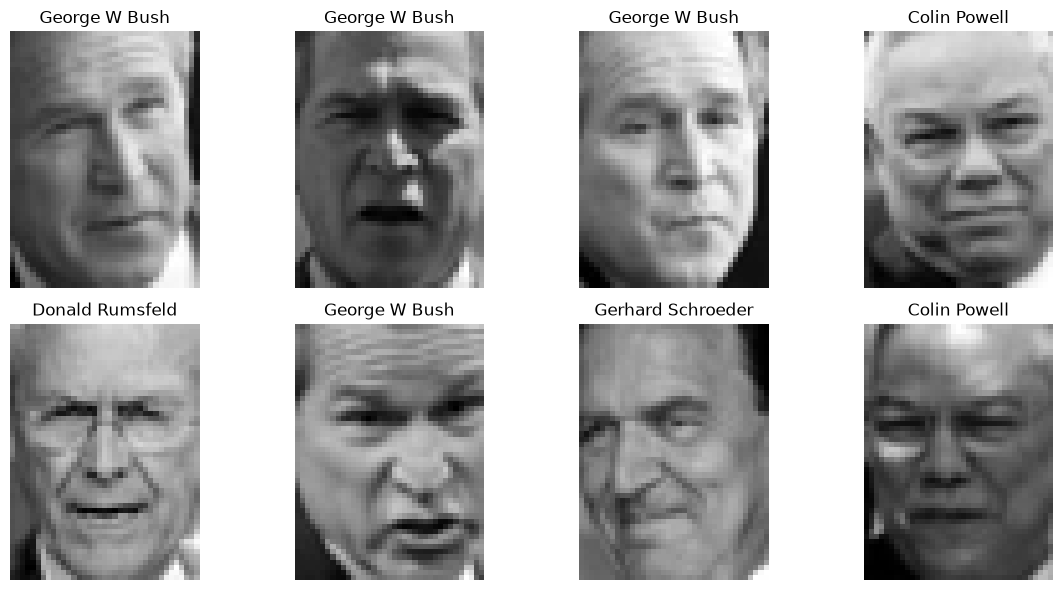

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(lfw_people.target_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=False
)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

model = Sequential([

    Input(shape=(50,37,1)),

    Conv2D(32,(3,3),padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(32,(3,3),padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.30),

    Conv2D(128,(3,3),padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.40),

    GlobalAveragePooling2D(),

    Dense(128,activation="relu"),

    Dropout(0.50),

    Dense(len(lfw_people.target_names),activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 37, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,543 (615.40 KB)

 Trainable params: 156,903 (612.90 KB)

 Non-trainable params: 640 (2.50 KB)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 37, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,543 (615.40 KB)

 Trainable params: 156,903 (612.90 KB)

 Non-trainable params: 640 (2.50 KB)

In [10]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_lfw_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [12]:
history = model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=32,
        shuffle=True
    ),

    validation_data=(X_test, y_test),

    epochs=60,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/60
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2974 - loss: 2.0332
Epoch 1: val_accuracy improved from None to 0.40698, saving model to best_lfw_model.keras

Epoch 1: finished saving model to best_lfw_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2971 - loss: 2.0330 - val_accuracy: 0.4070 - val_loss: 1.9267 - learning_rate: 5.0000e-04
Epoch 2/60
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3828 - loss: 1.7150
Epoch 2: val_accuracy did not improve from 0.40698
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3825 - loss: 1.7199 - val_accuracy: 0.1008 - val_loss: 1.9431 - learning_rate: 5.0000e-04
Epoch 3/60
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4319 - loss: 1.6257
Epoch 3: val_accuracy did not improve from 0.40698
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4291 - loss: 1.6341 - val_accuracy: 0.0659 - val_loss: 1.9469 - learning_rate: 5.0000e-04
Epoch 4/60
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.